<a href="https://colab.research.google.com/github/omotunjihenry001/AI-Powered-Threat-Intelligence-and-Decision-Support-System/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
pip install pandas requests python-dotenv

In [16]:
import requests
import pandas as pd

import os

API_KEY = os.getenv("NEWS_API_KEY")

url = "https://newsapi.org/v2/everything"

params = {
    "q": "cyber attack OR data breach OR fraud OR security threat",
    "language": "en",
    "sortBy": "publishedAt",
    "pageSize": 50,
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

articles = data.get("articles", [])

# Extract useful fields
records = []
for article in articles:
    records.append({
        "title": article["title"],
        "description": article["description"],
        "content": article["content"],
        "source": article["source"]["name"],
        "published_at": article["publishedAt"],
        "url": article["url"]
    })

df = pd.DataFrame(records)

# Save dataset
df.to_csv("osint_data.csv", index=False)

print("Data collected:", df.shape)
print(df.head())

Data collected: (50, 6)
                                               title  \
0  Wake up to machine-speed AI threats: Secure th...   
1  Report links anti-Christian extremism and 'ass...   
2  Toy Story 5 Blinks at Yet Another Toy-pocalyps...   
3  Bitdefender Antivirus Plus (1 Device): 1-Year ...   
4  Bitdefender Antivirus Plus (1 Device): 1-Year ...   

                                         description  \
0  Firewalls won't save you when your own AI agen...   
1  A new report links anti-Christian extremism an...   
2  Another existential crisis for playthings reve...   
3  Expires June 23, 2126 07:59 PST\n\n\n\n\n Buy ...   
4  Expires June 23, 2126 07:59 PST\n\n\n\n\n Buy ...   

                                             content             source  \
0  When an agent can make independent decisions, ...     Techtarget.com   
1  FIRST ON FOX: A new report reveals that a dang...           Fox News   
2  Even in this franchise-crazed world of ours, t...    Consequence.net   
3 

In [17]:
import pandas as pd

# Load your dataset
df = pd.read_csv("osint_data.csv")

print("Before cleaning:", df.shape)

# Drop rows with missing important text
df = df.dropna(subset=["title", "description"])

# Combine text fields into one column
df["text"] = df["title"] + " " + df["description"]

# Remove duplicates
df = df.drop_duplicates(subset=["text"])

# Basic cleaning
df["text"] = df["text"].str.lower()

print("After cleaning:", df.shape)

# Save cleaned data
df.to_csv("cleaned_osint_data.csv", index=False)

print(df[["text"]].head())

Before cleaning: (50, 6)
After cleaning: (44, 7)
                                                text
0  wake up to machine-speed ai threats: secure th...
1  report links anti-christian extremism and 'ass...
2  toy story 5 blinks at yet another toy-pocalyps...
3  bitdefender antivirus plus (1 device): 1-year ...
9  check point and illumio expand partnership to ...


In [18]:
import pandas as pd

df = pd.read_csv("cleaned_osint_data.csv")

print(df.head())

# Define threat keywords
threat_keywords = [
    "cyber attack", "ransomware", "data breach",
    "fraud", "hacking", "malware", "phishing",
    "exploit", "vulnerability", "ddos", "leak"
]

# Create label column
def label_threat(text):
    for word in threat_keywords:
        if word in text:
            return 1  # Threat
    return 0  # Not threat

df["label"] = df["text"].apply(label_threat)

print(df["label"].value_counts())

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,2))

X = vectorizer.fit_transform(df["text"])
y = df["label"]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
      stratify=y
)

# Train model
model = LogisticRegression(class_weight="balanced")
model = RandomForestClassifier(class_weight="balanced")
model.fit(X_train, y_train)

from sklearn.metrics import classification_report
y_probs = model.predict_proba(X_test)[:, 1]

# Lower threshold (from 0.5 → 0.3)
y_pred = (y_probs > 0.3).astype(int)
print("Predicted probabilities:", y_probs[:10])
print(classification_report(y_test, y_pred))

# Save probabilities for all data (not just test)
df["ml_score"] = model.predict_proba(X)[:, 1]

df.to_csv("model_output.csv", index=False)




                                               title  \
0  Wake up to machine-speed AI threats: Secure th...   
1  Report links anti-Christian extremism and 'ass...   
2  Toy Story 5 Blinks at Yet Another Toy-pocalyps...   
3  Bitdefender Antivirus Plus (1 Device): 1-Year ...   
4  Check Point and Illumio Expand Partnership to ...   

                                         description  \
0  Firewalls won't save you when your own AI agen...   
1  A new report links anti-Christian extremism an...   
2  Another existential crisis for playthings reve...   
3  Expires June 23, 2126 07:59 PST\n\n\n\n\n Buy ...   
4  As frontier AI models compress the entire atta...   

                                             content             source  \
0  When an agent can make independent decisions, ...     Techtarget.com   
1  FIRST ON FOX: A new report reveals that a dang...           Fox News   
2  Even in this franchise-crazed world of ours, t...    Consequence.net   
3  Note: This offer is ava

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("model_output.csv")

# Ensure ml_score exists
if "ml_score" not in df.columns:
    df["ml_score"] = 0.2  # fallback

# Risk scoring function
def get_base_score(text):
    text = text.lower()

    high_risk = [
        "ransomware", "data breach", "cyber attack",
        "cyber-attacks", "breach", "leak", "hacked"
    ]

    medium_risk = [
        "fraud", "malware", "phishing",
        "attack", "exploit", "vulnerability"
    ]

    score = 0

    for word in high_risk:
        if word in text:
            score += 3

    for word in medium_risk:
        if word in text:
            score += 1

    return score

# Apply scoring
df["base_score"] = df["text"].apply(get_base_score)

# Normalize
max_score = df["base_score"].max()

if max_score == 0:
    df["risk_score"] = 0
else:
    df["risk_score"] = df["base_score"] / max_score

# Combine scores
df["final_score"] = (df["risk_score"] * 0.7) + (df["ml_score"] * 0.3)

# Classify risk
def classify_risk(score):
    if score > 0.6:
        return "High"
    elif score > 0.3:
        return "Medium"
    else:
        return "Low"

df["risk_level"] = df["final_score"].apply(classify_risk)


# AI SUMMARY GENERATION

def generate_summary(text):

    sentences = text.split(". ")

    if len(sentences) >= 2:
        return ". ".join(sentences[:2])

    return text[:200]

df["summary"] = df["text"].apply(generate_summary)


# RISK EXPLANATION

def explain_risk(text, level, score):

    if level == "High":
        return (
            f"High risk article detected with risk score "
            f"{round(score,2)}. Multiple cyber threat indicators "
            f"such as attacks, breaches or malicious activities "
            f"were identified."
        )

    elif level == "Medium":
        return (
            f"Medium risk article detected with risk score "
            f"{round(score,2)}. Some threat-related indicators "
            f"were identified and should be monitored."
        )

    else:
        return (
            f"Low risk article detected with risk score "
            f"{round(score,2)}. No significant threat indicators "
            f"were found."
        )

df["risk_explanation"] = df.apply(
    lambda row: explain_risk(
        row["text"],
        row["risk_level"],
        row["final_score"]
    ),
    axis=1
)
# RECOMMENDATION ENGINE

def recommendation(level):

    if level == "High":
        return (
            "Immediate investigation recommended. "
            "Review security controls and assess potential impact."
        )

    elif level == "Medium":
        return (
            "Monitor developments and review defensive measures."
        )

    else:
        return (
            "Continue routine monitoring."
        )

df["recommendation"] = df["risk_level"].apply(recommendation)

# ANALYST REPORT

df["analyst_report"] = (
    "SUMMARY: " + df["summary"] +
    "\n\nRISK LEVEL: " + df["risk_level"] +
    "\n\nEXPLANATION: " + df["risk_explanation"] +
    "\n\nRECOMMENDED ACTION: " + df["recommendation"]
)
# Show results
print(
    df[
        [
            "summary",
            "risk_level",
            "recommendation"
        ]
    ].head()
)

df.to_csv("risk_output.csv", index=False)

                                             summary risk_level  \
0  wake up to machine-speed ai threats: secure th...        Low   
1  report links anti-christian extremism and 'ass...        Low   
2  toy story 5 blinks at yet another toy-pocalyps...        Low   
3  bitdefender antivirus plus (1 device): 1-year ...        Low   
4  check point and illumio expand partnership to ...     Medium   

                                      recommendation  
0                       Continue routine monitoring.  
1                       Continue routine monitoring.  
2                       Continue routine monitoring.  
3                       Continue routine monitoring.  
4  Monitor developments and review defensive meas...  


In [20]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.set_page_config(page_title="OSINT Threat Intelligence", layout="wide")

st.title("🛡️ AI-Powered OSINT Threat Intelligence Dashboard")

# Load data
df = pd.read_csv("risk_output.csv")

# Sidebar filter
st.sidebar.header("Filter Options")
risk_filter = st.sidebar.selectbox("Select Risk Level", ["All", "High", "Medium", "Low"])

# Apply filter
if risk_filter != "All":
    df_filtered = df[df["risk_level"] == risk_filter]
else:
    df_filtered = df

# Metrics
st.subheader("📊 Risk Summary")
col1, col2, col3 = st.columns(3)

col1.metric("High Risk", len(df[df["risk_level"] == "High"]))
col2.metric("Medium Risk", len(df[df["risk_level"] == "Medium"]))
col3.metric("Low Risk", len(df[df["risk_level"] == "Low"]))

# Table
st.subheader("📄 Threat Intelligence Feed")
st.dataframe(
    df_filtered[
        [
            "summary",
            "risk_level",
            "final_score",
            "recommendation"
        ]
    ]
)

# Top risks
st.subheader("🔝 Top Risks")
top_risks = df.sort_values(by="final_score", ascending=False).head(5)
st.dataframe(top_risks[["text", "risk_level", "final_score"]])
st.subheader("🤖 AI Analyst Reports")

selected = st.selectbox(
    "Select Article",
    df.index
)

st.text_area(
    "Analyst Report",
    df.loc[selected, "analyst_report"],
    height=300
)

Overwriting app.py


In [21]:
%%writefile app.py

import streamlit as st
import pandas as pd

st.set_page_config(page_title="OSINT Threat Intelligence", layout="wide")

st.title("🛡️ AI-Powered OSINT Threat Intelligence Dashboard")

df = pd.read_csv("risk_output.csv")

st.subheader("Threat Feed")

st.dataframe(
    df[["text","risk_level","final_score"]]
)


Overwriting app.py


In [22]:
!pip install streamlit pyngrok

In [23]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

!streamlit run app.py --server.port 8501 &

ERROR:pyngrok.process.ngrok:t=2026-06-17T16:24:28+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
import streamlit as st
import pandas as pd

st.set_page_config(page_title="OSINT Threat Intelligence", layout="wide")

st.title("🛡️ AI-Powered OSINT Threat Intelligence Dashboard")

# Load data
df = pd.read_csv("risk_output.csv")

# Sidebar filter
st.sidebar.header("Filter Options")
risk_filter = st.sidebar.selectbox("Select Risk Level", ["All", "High", "Medium", "Low"])

# Apply filter
if risk_filter != "All":
    df_filtered = df[df["risk_level"] == risk_filter]
else:
    df_filtered = df

# Metrics
st.subheader("📊 Risk Summary")
col1, col2, col3 = st.columns(3)

col1.metric("High Risk", len(df[df["risk_level"] == "High"]))
col2.metric("Medium Risk", len(df[df["risk_level"] == "Medium"]))
col3.metric("Low Risk", len(df[df["risk_level"] == "Low"]))

# Table
st.subheader("📄 Threat Intelligence Feed")
st.dataframe(df_filtered[["text", "risk_level", "final_score"]])

# Sort option
st.subheader("🔝 Top Risks")
top_risks = df.sort_values(by="final_score", ascending=False).head(5)
st.dataframe(top_risks[["text", "risk_level", "final_score"]])

In [24]:
from google.colab import files
files.download("risk_output.csv")
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import pandas as pd

df = pd.read_csv("risk_output.csv")

print(df.shape)
print(df.columns)
print(df.head())

(44, 17)
Index(['title', 'description', 'content', 'source', 'published_at', 'url',
       'text', 'label', 'ml_score', 'base_score', 'risk_score', 'final_score',
       'risk_level', 'summary', 'risk_explanation', 'recommendation',
       'analyst_report'],
      dtype='object')
                                               title  \
0  Wake up to machine-speed AI threats: Secure th...   
1  Report links anti-Christian extremism and 'ass...   
2  Toy Story 5 Blinks at Yet Another Toy-pocalyps...   
3  Bitdefender Antivirus Plus (1 Device): 1-Year ...   
4  Check Point and Illumio Expand Partnership to ...   

                                         description  \
0  Firewalls won't save you when your own AI agen...   
1  A new report links anti-Christian extremism an...   
2  Another existential crisis for playthings reve...   
3  Expires June 23, 2126 07:59 PST\n\n\n\n\n Buy ...   
4  As frontier AI models compress the entire atta...   

                                             

In [26]:
!streamlit run app.py --server.port 8501 &



2026-06-17 16:33:38.427 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.199.193.144:8501

  Stopping...


In [27]:
import pandas as pd

df = pd.read_csv("risk_output.csv")

print(df[["text","risk_level","final_score"]].head(10))

                                                text risk_level  final_score
0  wake up to machine-speed ai threats: secure th...        Low     0.009000
1  report links anti-christian extremism and 'ass...        Low     0.021000
2  toy story 5 blinks at yet another toy-pocalyps...        Low     0.015000
3  bitdefender antivirus plus (1 device): 1-year ...        Low     0.051000
4  check point and illumio expand partnership to ...     Medium     0.481667
5  world wide technology launches ‘defending at t...        Low     0.003000
6  how (and why) ai is eroding democracy in the u...        Low     0.057000
7  tekstream launches proactive cyber defense to ...        Low     0.027000
8  blackcore: israel runs secret avatar army to h...        Low     0.006000
9  copia raises $26m in funding to unify ot code ...        Low     0.009000


In [28]:
top_risks = (
    df.sort_values("final_score", ascending=False)
      .head(10)
)

print(top_risks[["text","risk_level","final_score"]])

                                                 text risk_level  final_score
37  biggest healthcare data breaches reported to o...       High     0.772000
29  ransomware gang abuses microsoft teams relays ...       High     0.664667
17  netcraft preemptive domain disruption wins bes...     Medium     0.527000
4   check point and illumio expand partnership to ...     Medium     0.481667
28  attackers exploit three fortinet fortisandbox ...     Medium     0.443333
39  cybersecurity jobs available right now: june 1...     Medium     0.437333
16  improving precision in ctem: how continuous co...     Medium     0.434333
32  critical fortinet fortisandbox flaws now explo...     Medium     0.434333
22  beyond mythos: responding to a new threat land...     Medium     0.332667
19  cisa adds one known exploited vulnerability to...     Medium     0.317333


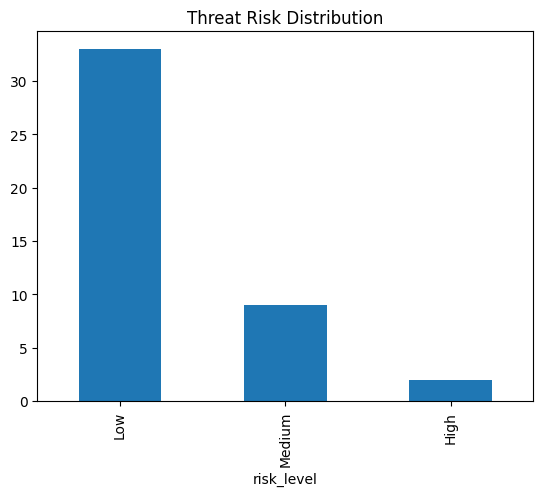

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("risk_output.csv")

df["risk_level"].value_counts().plot(kind="bar")

plt.title("Threat Risk Distribution")

plt.show()

In [30]:
top = df.sort_values(
    "final_score",
    ascending=False
).head(5)

top[["text","final_score"]]

,text,final_score
37,biggest healthcare data breaches reported to o...,0.772000
29,ransomware gang abuses microsoft teams relays ...,0.664667
17,netcraft preemptive domain disruption wins bes...,0.527000
4,check point and illumio expand partnership to ...,0.481667
28,attackers exploit three fortinet fortisandbox ...,0.443333
